<a href="https://colab.research.google.com/github/exeliuioar/MachineLearningLab/blob/main/Test-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initialization

In [3]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

Loading Dataset

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
df = pd.read_csv(url, header=None)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Visualization

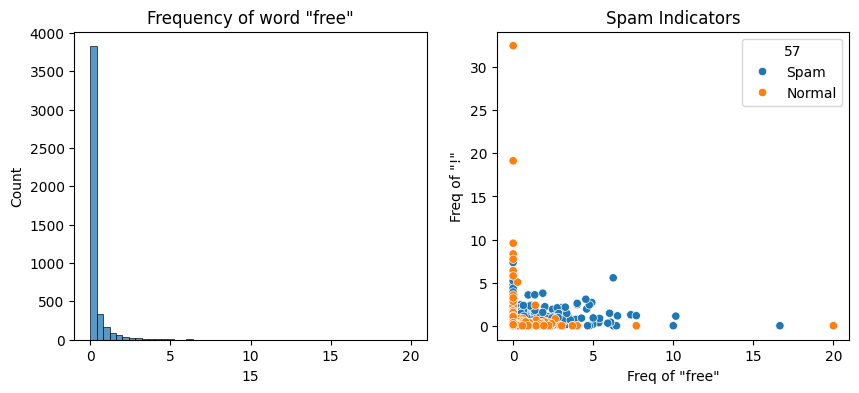

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X.iloc[:, 15], bins=50, ax=ax[0]).set_title('Frequency of word "free"')
sns.scatterplot(x=X.iloc[:, 15], y=X.iloc[:, 51], hue=y.map({0: 'Normal', 1: 'Spam'}), ax=ax[1])
ax[1].set(xlabel='Freq of "free"', ylabel='Freq of "!"', title='Spam Indicators')
plt.show()

Training

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

Accuracy and Confusion Matrix

Model Accuracy on Real Data: 95.55%


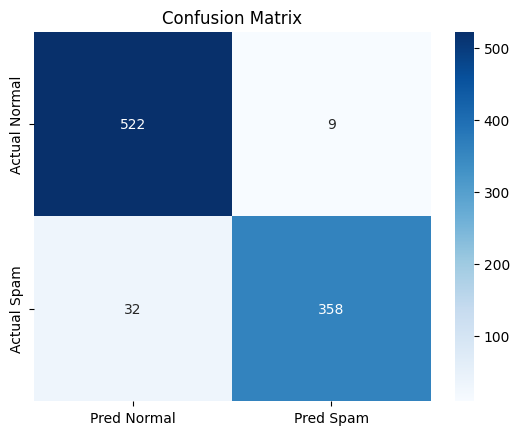

In [13]:
print(f"Model Accuracy on Real Data: {accuracy_score(y_test, y_pred):.2%}")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Spam'], yticklabels=['Actual Normal', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.show()